# 1. Introduction & Problem Statement

Customer churn prediction aims to identify customers who are likely to discontinue a service.  
This is a binary classification problem with churn as the positive class.

The dataset is imbalanced, with a significantly smaller proportion of churned customers.  
Therefore, ROC-AUC is used as the primary evaluation metric, as it is robust to class imbalance.

The objective of this project is to build and compare multiple machine learning models, handle class imbalance appropriately, and select a final model that balances performance, stability, and interpretability.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 


df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')

df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


# 2. Data Overview + Preprocessing

In [2]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [3]:
df['Churn'].value_counts(normalize=True)

No     0.73463
Yes    0.26537
Name: Churn, dtype: float64

In [4]:
df['TotalCharges'].dtype
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = 'coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace = True)
df['TotalCharges'].isna().sum()

0

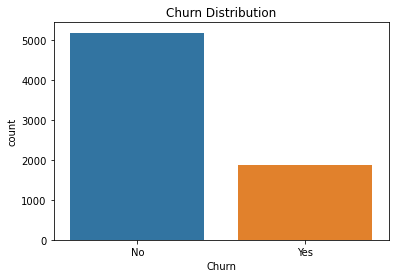

In [5]:
sns.countplot( x = 'Churn', data= df)
plt.title('Churn Distribution')
plt.show()

In [6]:
df['Contract'].unique()

array(['Month-to-month', 'One year', 'Two year'], dtype=object)

The target is imbalanced (majority non-churn). ROC-AUC is used for model comparison and we later tune the decision threshold.

<AxesSubplot:xlabel='tenure', ylabel='churn_pct'>

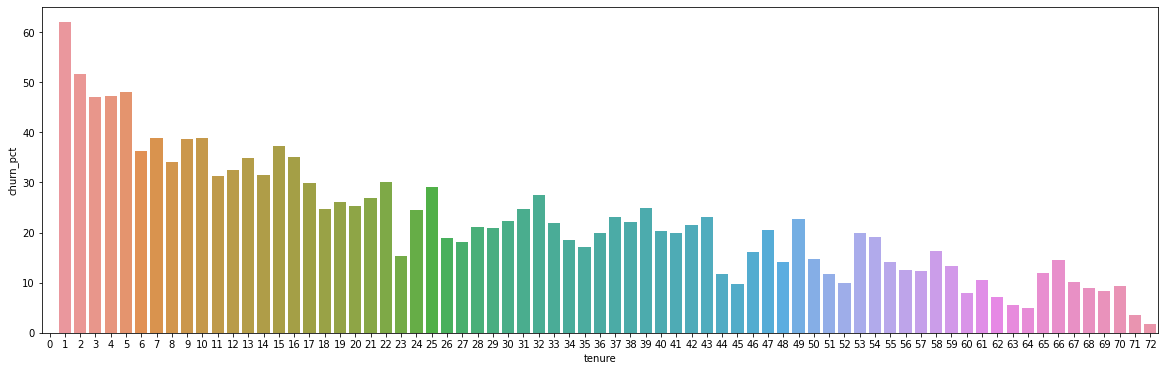

In [7]:
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})
churn_by_tenure = df.groupby('tenure')['Churn'].mean().reset_index()
churn_by_tenure['churn_pct'] = churn_by_tenure['Churn']*100
plt.figure(figsize = (20,6))
sns.barplot(data = churn_by_tenure, x = 'tenure', y = 'churn_pct' )

Churn rate is highest for low-tenure customers and decreases as tenure increases. This suggests tenure is a strong predictor and motivates binned tenure features or interactions with contract type.

<AxesSubplot:xlabel='tenure', ylabel='churn_pct'>

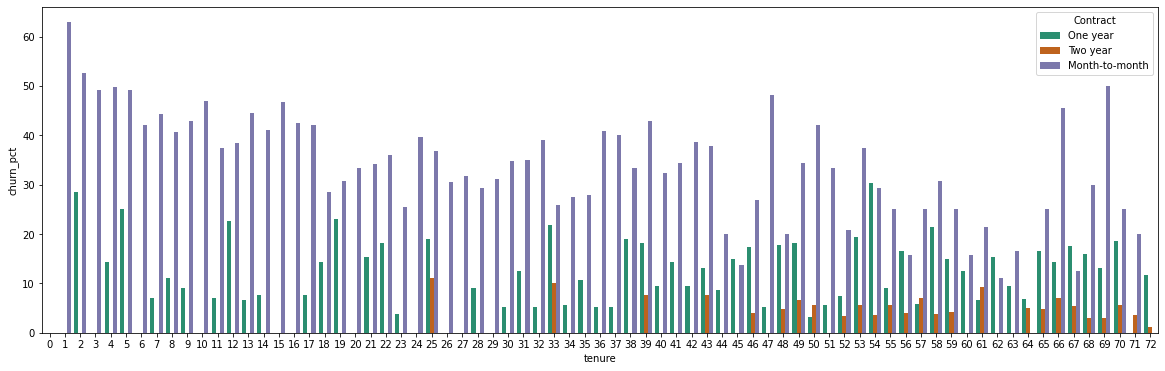

In [8]:
pivot = (df.groupby(['tenure', 'Contract'])['Churn'].mean().reset_index())
pivot['churn_pct'] = pivot['Churn']*100
plt.figure(figsize=(20,6))
sns.barplot(data = pivot, x='tenure', y = 'churn_pct', hue = 'Contract', palette = 'Dark2')

Customers with higher monthly charges tend to churn more often. This indicates price sensitivity and supports testing interactions between MonthlyCharges and Contract type.

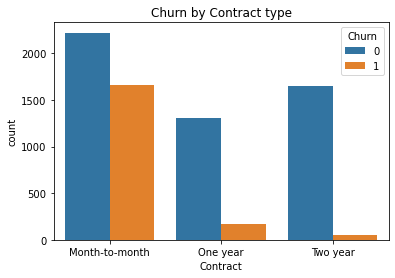

In [9]:
sns.countplot(x='Contract', hue = 'Churn', data = df)
plt.title('Churn by Contract type')
plt.show()

Churn rates differ noticeably by payment method, suggesting that payment behavior is informative and may capture customer friction or commitment differences.

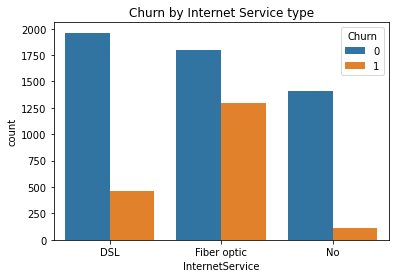

In [10]:
sns.countplot(x = 'InternetService', hue = 'Churn', data=df)
plt.title('Churn by Internet Service type')
plt.show()

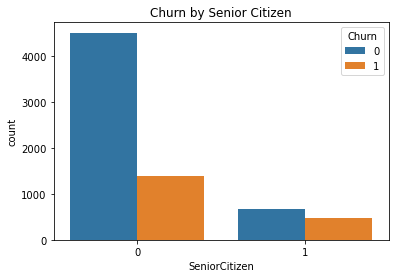

In [11]:
sns.countplot(x = 'SeniorCitizen', hue ='Churn', data = df)
plt.title('Churn by Senior Citizen')
plt.show()

In [12]:
yes_no_cols = [col for col in df.columns if df[col].isin(['Yes','No']).any()]
yes_no_cols.remove("InternetService")
for col in yes_no_cols:
    df[col].replace({'Yes':1, 'No':0}, inplace = True)

In [13]:
binary_cols = [col for col in df.columns 
                  if set(df[col].dropna().unique()).issubset({0,1})]
non_binary_cols = [c for c in yes_no_cols if c not in binary_cols]
non_binary_cols_internet = [c for c in non_binary_cols if c!= 'MultipleLines']
for col in non_binary_cols_internet:
    df[col] = df[col].replace({'No internet service':0})
df['MultipleLines'].replace({'No phone service':0}, inplace=True)

In [14]:
df = df.drop(['customerID', 'PaymentMethod'], axis =1)

In [15]:
df = pd.get_dummies(df)

# 3. Modeling

## 3.1. Baseline modeling: Logistic Regression

In [16]:
from sklearn.model_selection import train_test_split
X = df.drop('Churn', axis =1)
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size =0.2, random_state = 42)

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lr_model = LogisticRegression(solver="liblinear", class_weight ="balanced",  max_iter=1000)
scores_lr = cross_val_score(lr_model, X,y, cv = cv, scoring = "roc_auc")
lr_model.fit(X_train, y_train)
y_pred = lr_model.predict(X_test)

In [18]:
lr_model.score(X_test, y_test)

0.7601135557132718

In [19]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, roc_curve, auc

confusion_matrix(y_test, y_pred, normalize="true")

array([[0.73359073, 0.26640927],
       [0.16621984, 0.83378016]])

In [20]:
precision_score(y_test, y_pred)

0.5298126064735945

In [21]:
recall_score(y_test, y_pred)

0.8337801608579088

In [22]:
y.value_counts(normalize = True)

0    0.73463
1    0.26537
Name: Churn, dtype: float64

In [23]:
y_proba = lr_model.predict_proba(X_test)[:,1]
thresholds = [0.3, 0.4, 0.6, 0.8]
preds = {t: (y_proba >= t).astype(int) for t in thresholds}

In [24]:
results = []
for t, y_pred in preds.items():
    results.append({
        'Threshold': t,
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    })
df_results = pd.DataFrame(results).set_index('Threshold')
print(df_results)

           Precision    Recall  F1-Score
Threshold                               
0.3         0.423402  0.941019  0.584027
0.4         0.461644  0.903485  0.611061
0.6         0.573805  0.739946  0.646370
0.8         0.741627  0.415550  0.532646


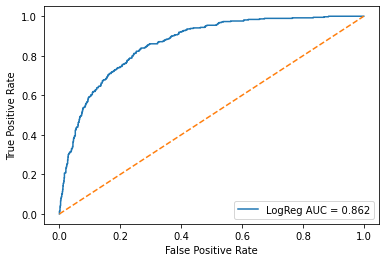

In [25]:
# Probabilities
y_proba = lr_model.predict_proba(X_test)[:, 1]

# ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba)

auc_lr = auc(fpr_lr, tpr_lr)

# Plot
plt.plot(fpr_lr, tpr_lr, label=f"LogReg AUC = {auc_lr:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

## 3.2. Random Forest

In [26]:
from sklearn.ensemble import RandomForestClassifier
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
scores_rf = cross_val_score(rf_model, X,y, cv = cv, scoring = "roc_auc")
rf_model.fit(X_train, y_train)
y_pred_rf= rf_model.predict(X_test)
recall_score(y_test, y_pred_rf), precision_score(y_test, y_pred_rf)

(0.4772117962466488, 0.6334519572953736)

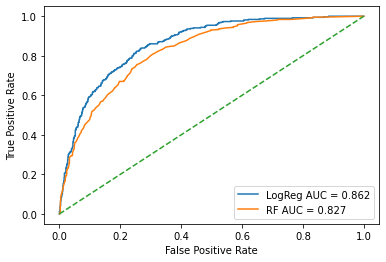

In [27]:
# Probabilities
y_proba = lr_model.predict_proba(X_test)[:, 1]
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

auc_lr = auc(fpr_lr, tpr_lr)
auc_rf = auc(fpr_rf, tpr_rf)

# Plot
plt.plot(fpr_lr, tpr_lr, label=f"LogReg AUC = {auc_lr:.3f}")
plt.plot(fpr_rf, tpr_rf, label=f"RF AUC = {auc_rf:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

## 3.3. Gradient Boosting

In [28]:
from sklearn.ensemble import GradientBoostingClassifier
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=1.0,
    max_depth=1, random_state=0)
scores_gb = cross_val_score(gb_model, X,y, cv = cv, scoring = "roc_auc")
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)
recall_score(y_test, y_pred_gb), precision_score(y_test, y_pred_gb)

(0.5710455764075067, 0.6870967741935484)

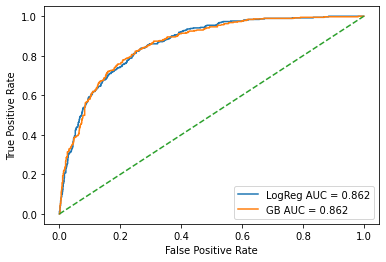

In [29]:
# Probabilities
y_proba = lr_model.predict_proba(X_test)[:, 1]
y_proba_gb = gb_model.predict_proba(X_test)[:, 1]

# ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_proba_gb)

auc_lr = auc(fpr_lr, tpr_lr)
auc_gb = auc(fpr_gb, tpr_gb)

# Plot
plt.plot(fpr_lr, tpr_lr, label=f"LogReg AUC = {auc_lr:.3f}")
plt.plot(fpr_gb, tpr_gb, label=f"GB AUC = {auc_gb:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

A small, targeted hyperparameter search was conducted over learning rate, tree depth, and number of estimators using cross-validated ROC-AUC.

In [30]:
configs = [
    {"n_estimators": 100, "learning_rate": 0.1, "max_depth": 1},
    {"n_estimators": 100, "learning_rate": 1.0, "max_depth": 1},
    {"n_estimators": 300, "learning_rate": 1.0, "max_depth": 1},
    {"n_estimators": 500, "learning_rate": 0.1, "max_depth": 1},
    {"n_estimators": 500, "learning_rate": 0.1, "max_depth": 2},
]

results = []

for cfg in configs:
    model = GradientBoostingClassifier(
        random_state=42,
        **cfg
    )
    score = cross_val_score(
        model, X, y, cv=5, scoring="roc_auc"
    ).mean()
    
    results.append({**cfg, "roc_auc": score})

results_df = pd.DataFrame(results)
results_df.sort_values("roc_auc", ascending=False)
results_df = results_df.sort_values("roc_auc", ascending=False).reset_index(drop=True)
results_df

,n_estimators,learning_rate,max_depth,roc_auc
0,500,0.1,1,0.847780
1,100,1.0,1,0.846283
2,300,1.0,1,0.843514
3,100,0.1,1,0.843348
4,500,0.1,2,0.839832


In [31]:
binary_cols_no_churn = [c for c in binary_cols if c!= "Churn"]

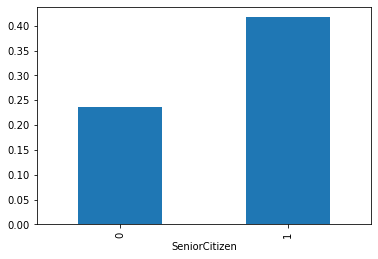

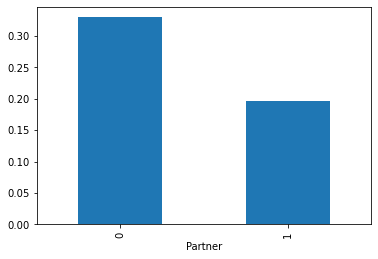

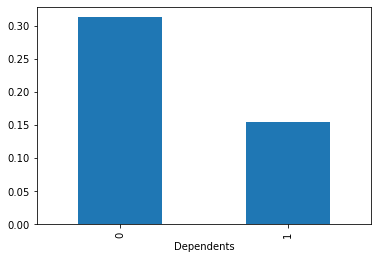

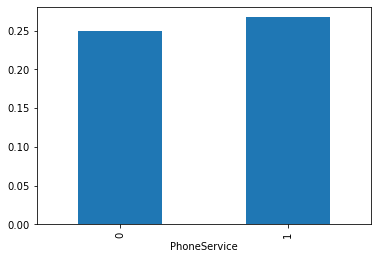

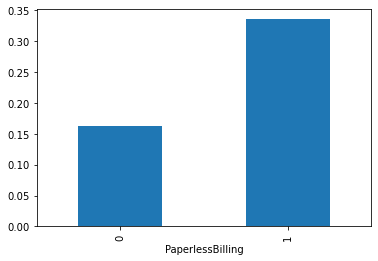

In [32]:
for col in binary_cols_no_churn:
    df.groupby(col)['Churn'].mean().plot(kind = "bar")
    plt.xlabel(col)
    plt.show()

In [33]:
risky_binary_cols = [c for c in binary_cols_no_churn if c!= 'PhoneService']
df['risk_count'] = df[risky_binary_cols].sum(axis=1)

In [34]:
X['risk_count'] = df['risk_count']

In [35]:
model = LogisticRegression(solver="liblinear", class_weight ="balanced",  max_iter=1000)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X,y, cv = cv, scoring = "roc_auc")
scores.mean()

0.8438222573020274

In [36]:
df = df.drop('risk_count', axis =1)

## 3.4. Histogram-Based Gradient Boosting

In [37]:
from sklearn.ensemble import HistGradientBoostingClassifier
hgb_model = HistGradientBoostingClassifier(
    max_depth=1,
    learning_rate=0.09,
    max_iter=500,
    random_state=42
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_hgb = cross_val_score(hgb_model, X,y, cv = cv, scoring = "roc_auc")
hgb_model.fit(X_train, y_train)
scores_hgb.mean()

0.8475714797299163

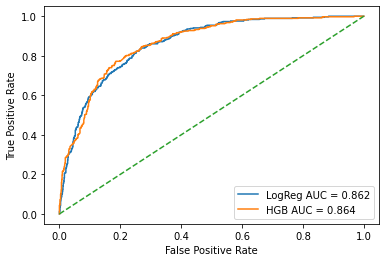

In [38]:
# Probabilities
y_proba = lr_model.predict_proba(X_test)[:, 1]
y_proba_hgb = hgb_model.predict_proba(X_test)[:, 1]

# ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba)
fpr_hgb, tpr_hgb, _ = roc_curve(y_test, y_proba_hgb)

auc_lr = auc(fpr_lr, tpr_lr)
auc_hgb = auc(fpr_hgb, tpr_hgb)

# Plot
plt.plot(fpr_lr, tpr_lr, label=f"LogReg AUC = {auc_lr:.3f}")
plt.plot(fpr_hgb, tpr_hgb, label=f"HGB AUC = {auc_hgb:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# 3. Model Comparison

Models were compared using 5-fold stratified cross-validation with ROC-AUC due to class imbalance.

In [39]:
results = []
results.append({
    "Model": "Logistic Regression",
    "CV ROC-AUC": scores_lr.mean(),
    "Notes": "class_weight=balanced"
})

results.append({
    "Model": "Random Forest",
    "CV ROC-AUC": scores_rf.mean(),
    "Notes": "baseline"
})

results.append({
    "Model": "Gradient Boosting (tuned)",
    "CV ROC-AUC": scores_gb.mean(),
    "Notes": "final model"
})
results.append({
    "Model": "HistGradientBoosting",
    "CV ROC-AUC": scores_hgb.mean(),
    "Notes": "no meaningful gain over GB"
})
results_df = pd.DataFrame(results)
results_df.sort_values("CV ROC-AUC", ascending=False).reset_index(drop=True)
print(results_df)

                       Model  CV ROC-AUC                       Notes
0        Logistic Regression    0.844114       class_weight=balanced
1              Random Forest    0.818255                    baseline
2  Gradient Boosting (tuned)    0.845879                 final model
3       HistGradientBoosting    0.847571  no meaningful gain over GB


# 4. Conclusion & Next Steps

In this project, customer churn was modeled as a binary classification problem using a structured, end-to-end machine learning workflow.  
Exploratory analysis revealed strong relationships between churn, customer tenure, contract type, and pricing, motivating the use of non-linear models.

Several models were evaluated, including Logistic Regression, Random Forest, and multiple Gradient Boosting variants, using stratified cross-validation and ROC-AUC as the primary metric to account for class imbalance.  
A tuned Gradient Boosting model achieved the best balance of performance and stability, while more complex variants did not provide meaningful additional gains.

Overall, results suggest that model performance is primarily constrained by feature signal rather than model complexity.  
Future improvements could focus on richer feature engineering, temporal customer behavior, or cost-sensitive decision thresholds for deployment.

## Feature Importance 

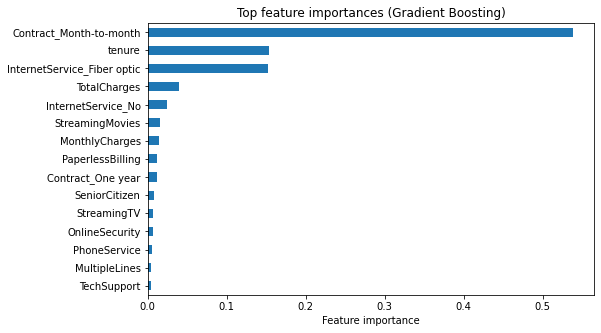

In [40]:
gb_model.fit(X, y)

importance = pd.Series(
    gb_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(8,5))
importance.head(15).plot(kind="barh")
plt.gca().invert_yaxis()
plt.xlabel("Feature importance")
plt.title("Top feature importances (Gradient Boosting)")
plt.show()

Feature importance from the Gradient Boosting model indicates that contract type and customer tenure are the dominant drivers of churn.  
Month-to-month contracts have the strongest contribution, followed by tenure, highlighting that short-term and less-committed customers are significantly more likely to churn.

Internet service type (particularly fiber optic) and pricing-related variables such as total and monthly charges also contribute to churn risk, though to a lesser extent.  
Most remaining service-related features have comparatively smaller importance, suggesting that churn is driven more by customer commitment and pricing structure than by individual service add-ons.
